# Atelier Préparation de Données Tabulaires

## Partie 1 – Explorer les données

### 1) Charger les données CSV

In [335]:
import pandas as pd
df = pd.read_csv("../data/smart_building_raw.csv")

### 2) Afficher les premières lignes du dataset

In [336]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


### 3) Afficher les dernières lignes du dataset

In [337]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


### 4) Combien d'observations contient le dataset ?

In [338]:
df.shape

(507, 14)

**Réponse.** Le dataset contient **507 observations** (lignes).

### 5) Combien de variables possède le dataset ?

In [339]:
df.shape[1]

14

**Réponse.** Le dataset possède **14 variables** (colonnes).

### 6) Identifier les variables numériques

In [340]:
df.dtypes

id_mesure               int64
date                      str
batiment                  str
type_batiment             str
zone                      str
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation        str
etat_systeme              str
jour_semaine              str
alerte                    str
dtype: object

In [341]:
# df.select_dtypes(include="number")
df.select_dtypes(include="number").columns

Index(['id_mesure', 'temperature', 'humidite', 'co2', 'occupation',
       'consommation_kwh'],
      dtype='str')

**Réponse.** Colonnes numériques *au sens du type* : `id_mesure`, `temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`.

Attention : `id_mesure` est un **identifiant** (il est fait de chiffres mais calculer sa moyenne n'a pas de sens). Les vraies variables numériques *exploitables comme mesures* sont donc les **5** autres : `temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`.

### 7) Identifier les variables catégorielles

In [342]:
df.select_dtypes(include = "str").columns

Index(['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation',
       'etat_systeme', 'jour_semaine', 'alerte'],
      dtype='str')

**Réponse.** Colonnes de type texte : `date`, `batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine`, `alerte`.

On écarte `date`, qui n'est pas une catégorie mais une date stockée en texte (elle sera convertie à la tâche 8). Les **7** vraies variables catégorielles sont : `batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine`, `alerte`.

> Note transversale : `select_dtypes` classe sur le **type de stockage**, pas sur le **sens** de la variable. `id_mesure` est stocké en nombre mais reste un identifiant ; `date` est stockée en texte mais reste une date.

### 8) Identifier les dates

**Première tentative (elle échoue volontairement).** La conversion directe :

```python
df["date"] = pd.to_datetime(df["date"])
```

lève l'erreur suivante :

```
ValueError: day 30 must be in range 1..28 for month 2 in year 2025
```

> **Ce que révèle l'erreur.** La conversion directe échoue avec `ValueError: day 30 must be in range 1..28 for month 2` : il existe des dates **impossibles** dans la colonne (par exemple un 30 février). C'est une **incohérence** (valeur physiquement invalide). Pandas refuse de deviner et s'arrête. On relance donc la conversion en neutralisant ces valeurs (cellule suivante).

In [343]:
# la conversion
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [344]:
# vérifier le type
df["date"].dtype

dtype('<M8[us]')

In [345]:
#compter les dates devenues manquantes
df["date"].isna().sum()

np.int64(5)

**Identification.** La seule variable de type date est `date`.

**Préparation (au-delà de la simple identification).** Contrairement aux variables numériques (tâche 6) et catégorielles (tâche 7), déjà reconnues telles quelles par pandas, une date lue depuis un CSV arrive stockée en **texte** (`str`) : pandas ne la "voit" pas comme une date. On la convertit donc avec `pd.to_datetime` pour établir son vrai type (`datetime64`, affiché ici `<M8[us]` par NumPy — `M8` = `datetime64`, `[us]` = précision à la microseconde).

La conversion a aussi révélé **5 dates impossibles** (ex. un 30 février), transformées en valeurs manquantes grâce à `errors="coerce"`. Cela anticipe la règle 12f de l'énoncé (une valeur manifestement erronée et non récupérable devient manquante) : la colonne `date` est donc déjà réglée pour les tâches 12-13. Une date manquante s'écrit `NaT` (*Not a Time*) : c'est, pour une colonne de dates, ce que `NaN` est pour une colonne de nombres.

**Intérêt de la conversion :** pouvoir extraire l'année / le mois / le jour / l'heure, trier chronologiquement, filtrer par période et calculer des durées — impossible tant que la colonne reste du texte.

### 9) Identifier les identifiants

In [346]:
df["id_mesure"].nunique()

500

**Réponse.** L'identifiant du dataset est `id_mesure` : c'est une étiquette qui numérote
chaque mesure (faite de chiffres, mais aucune moyenne n'a de sens dessus → ce n'est pas
une variable numérique exploitable, malgré son type `int64`).

`df["id_mesure"].nunique()` renvoie **500** pour **507** lignes : 7 numéros sont donc
répétés. `id_mesure` n'est pas parfaitement unique → signal de **doublons potentiels**,
à examiner à la tâche 14 (vrais doublons identiques, ou lignes distinctes partageant un
même id ?).

### 10) Statistiques : moyenne, médiane, min, max, écart-type et quartiles

In [347]:
df.describe()

,id_mesure,date,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,502,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,2025-03-04 13:26:03.346613,24.154141,57.864113,844.150000,44.850299,169.069323
min,1001.000000,2025-01-01 00:00:00,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,2025-02-01 01:30:00,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,2025-03-04 21:00:00,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,2025-04-04 22:30:00,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,2025-05-05 18:00:00,96.000000,160.000000,6000.000000,116.000000,336.200000
std,144.782769,NaN,7.418465,16.026336,582.181386,24.949139,53.164294


In [348]:
df.median(numeric_only=True)

id_mesure           1252.00
temperature           24.00
humidite              57.55
co2                  787.50
occupation            46.00
consommation_kwh     169.80
dtype: float64

**Réponse.** `df.describe()` fournit en une fois, pour chaque variable numérique :
`count` (valeurs non manquantes), `mean` (moyenne), `std` (écart-type), `min`, `max`,
et `25% / 50% / 75%` (les quartiles Q1, Q2, Q3). La **médiane** est la ligne `50%`,
confirmée par `df.median()` (ex. `temperature` : 24.00 dans les deux).

Variables potentiellement problématiques repérées dès les statistiques :
- `humidite` : min = −12 et max = 160 → **impossibles** (un % est entre 0 et 100) → incohérences (tâche 12) ;
- `temperature` : min = −30 et max = 96 → valeurs extrêmes suspectes → aberrantes probables (tâches 12, 15-16) ;
- `co2` : médiane ≈ 787 mais une valeur à 3900 → aberrante à examiner (tâche 16).

### 11) Y a-t-il des variables potentiellement problématiques ?

In [349]:
df.isna().sum()

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

**Réponse.** Oui, l'exploration révèle plusieurs variables problématiques, de natures différentes :

- **Incohérences** : `humidite` (valeurs < 0 et > 100, impossibles pour un %), `date` (dates impossibles, déjà mises en `NaT` à la tâche 8).
- **Valeurs aberrantes** : `temperature` (min −30, max 96), `co2` (valeur à 3900 vs médiane ≈ 787).
- **Valeurs manquantes** : plusieurs colonnes (voir `df.isna().sum()`), à quantifier à la tâche 13.
- **Doublons potentiels** : `id_mesure` a 500 valeurs uniques pour 507 lignes → à examiner à la tâche 14.

Ces problèmes seront traités dans les tâches suivantes (12 : incohérences, 13 : manquantes, 14 : doublons, 15-16 : aberrantes).

### 12) Données incohérentes

#### 12a) Rechercher les valeurs d'humidité < 0

In [350]:
df[df["humidite"] < 0 ]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


In [351]:
(df["humidite"] < 0).sum()

np.int64(3)

#### 12b) Rechercher les valeurs d'humidité > 100

In [352]:
df[df["humidite"] > 100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


In [353]:
(df["humidite"] > 100).sum()

np.int64(7)

#### 12c) Rechercher les valeurs de température extrêmement élevée

In [354]:
df[df["temperature"] > 50]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
499,1021,2025-01-06,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


In [355]:
(df["temperature"] > 50).sum()

np.int64(4)

**Justification du seuil.** Il n'existe pas de borne physique stricte pour la température
comme pour l'humidité. On fixe un seuil métier à **50 °C** : au-delà, une température
intérieure de bâtiment occupé n'est plus plausible (panne de capteur ou erreur de saisie).
Ce seuil est cohérent avec les statistiques (75 % des mesures ≤ 26 °C), donc il isole les
valeurs extrêmes (72.5 ; 88 ; 95.2 ; 96 °C) sans toucher aux températures normales.

#### 12d) Rechercher les valeurs négatives

In [356]:
colonnes_positives = ["co2", "occupation", "consommation_kwh"]
(df[colonnes_positives] < 0).sum()

co2                 0
occupation          5
consommation_kwh    4
dtype: int64

**Réponse (12d).** Une valeur négative n'est incohérente que sur les variables qui ne peuvent pas l'être physiquement : `co2`, `occupation`, `consommation_kwh`. On les vérifie sur ce sous-ensemble — résultats : `co2` = 0, `occupation` = 5, `consommation_kwh` = 4 valeurs négatives. On exclut `temperature` (une température peut légitimement être négative) et `humidite` (déjà traitée en 12a). `id_mesure` (identifiant) n'est pas concerné. Le cas particulier de la consommation négative est détaillé en 12e.

#### 12e) Rechercher les valeurs de consommation négative

In [357]:
df[df["consommation_kwh"] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


In [358]:
(df["consommation_kwh"] < 0).sum()

np.int64(4)

#### 12f) Transformer les valeurs erronées en valeurs manquantes

**Principe.** Une valeur manifestement fausse et non récupérable est remplacée par une valeur manquante (`NaN`), et non par la suppression de toute la ligne : les autres colonnes de la ligne sont souvent valides. On neutralise donc uniquement la case fautive (avec `df.loc[condition, "colonne"] = np.nan`). Les cases vides seront remplies à la tâche 13.

In [359]:
import numpy as np

# 12f — neutraliser en NaN les incohérences repérées en 12a–12e

# ligne-modèle (fournie) : humidité < 0  ->  NaN
df.loc[df["humidite"] < 0, "humidite"] = np.nan

# 1) humidité > 100        -> NaN   (colonne "humidite")
df.loc[df["humidite"] > 100, "humidite"] = np.nan
# 2) température > 50       -> NaN   (colonne "temperature")
df.loc[df["temperature"] > 50, "temperature"] = np.nan
# 3) occupation < 0         -> NaN   (colonne "occupation")
df.loc[df["occupation"] < 0, "occupation"] = np.nan
# 4) consommation_kwh < 0   -> NaN   (colonne "consommation_kwh")
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan


In [360]:
# Vérif 1 : toutes les recherches d'incohérences doivent renvoyer 0
print((df["humidite"] < 0).sum(), (df["humidite"] > 100).sum(),
      (df["temperature"] > 50).sum(), (df["occupation"] < 0).sum(),
      (df["consommation_kwh"] < 0).sum())

0 0 0 0 0


In [361]:
# Vérif 2 : le nombre de valeurs manquantes doit avoir augmenté
df.isna().sum()

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           16
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

#### 12g) Rechercher les catégories mal orthographiées

In [362]:
df["type_batiment"].value_counts()

type_batiment
Bureau               210
Centre commercial     65
École                 59
Hôpital               58
Entrepôt              52
Université            48
BUREAU                 2
ÉCOLE                  1
ecole                  1
Bureu                  1
bureau                 1
 UNIVERSITÉ            1
hôpital                1
centre commercial      1
 Bureau                1
entrepot               1
Name: count, dtype: int64

In [363]:
# Inspecter les autres colonnes catégorielles pour repérer variantes/espaces/fautes
for col in ["batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]:
    print("---", col, "---")
    print(df[col].value_counts())
    print()

--- batiment ---
batiment
B1    94
B5    66
B7    65
B2    61
B3    58
B4    58
B8    53
B6    52
Name: count, dtype: int64

--- zone ---
zone
B    143
A    125
D    124
C    115
Name: count, dtype: int64

--- mode_climatisation ---
mode_climatisation
Normal     271
Eco        131
Boost       96
normal       1
BOOST        1
normale      1
Normal       1
Name: count, dtype: int64

--- etat_systeme ---
etat_systeme
Normal    442
Alerte     52
Panne      13
Name: count, dtype: int64

--- jour_semaine ---
jour_semaine
Vendredi    75
Jeudi       74
Mercredi    73
Samedi      72
Dimanche    70
Lundi       69
Mardi       69
Name: count, dtype: int64

--- alerte ---
alerte
Non    361
Oui    146
Name: count, dtype: int64



**Réponse (12g).** Deux colonnes contiennent des catégories mal orthographiées : `type_batiment` et `mode_climatisation`. Les problèmes se rangent en trois familles :

- **Casse incohérente** : `BUREAU` / `bureau`, `ÉCOLE` / `ecole`, `hôpital`, `centre commercial` ; `normal`, `BOOST`.
- **Espaces parasites** : ` Bureau`, ` UNIVERSITÉ`, `Normal ` (espace final).
- **Fautes de frappe / accents manquants** : `Bureu` (→ bureau), `entrepot` (→ entrepôt), `normale` (→ normal).

Les autres colonnes (`batiment`, `zone`, `etat_systeme`, `jour_semaine`, `alerte`) sont propres.

La **casse** et les **espaces** se corrigent automatiquement en 12h (`.str.strip()` puis `.str.lower()`). Les **fautes de frappe** ne disparaissent pas avec ces opérations et demandent un remplacement explicite (optionnel, au-delà de ce que 12h exige).

#### 12h) Normaliser les catégories textuelles (supprimer les espaces, uniformiser la casse)

**Technique.** Sur une colonne de texte, l'accesseur `.str` donne accès aux opérations de chaînes appliquées à toute la colonne d'un coup :

- `.str.strip()` enlève les espaces au début et à la fin (` Bureau` → `Bureau`) ;
- `.str.lower()` met tout en minuscules (`BUREAU`, `bureau` → `bureau`).

En enchaînant les deux, toutes les variantes de casse et d'espaces d'une même catégorie fusionnent. On applique ça à toutes les colonnes catégorielles (les `NaN` restent `NaN`).

In [364]:
# 12h — normaliser espaces + casse sur les colonnes catégorielles

for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.strip().str.lower()

**(Optionnel, au-delà de 12h)** Après `strip`+`lower`, il reste les vraies fautes de frappe repérées en 12g : `bureu`, `entrepot`, `normale`. Elles ne fusionnent pas toutes seules et peuvent être corrigées explicitement avec `replace`, par exemple :

```python
df["type_batiment"] = df["type_batiment"].replace({"bureu": "bureau", "entrepot": "entrepôt"})
df["mode_climatisation"] = df["mode_climatisation"].replace({"normale": "normal"})
```

In [365]:
# Vérif : après normalisation, chaque colonne doit avoir moins de catégories, toutes propres
print(df["type_batiment"].value_counts())
print()
print(df["mode_climatisation"].value_counts())

type_batiment
bureau               214
centre commercial     66
école                 60
hôpital               59
entrepôt              52
université            49
ecole                  1
bureu                  1
entrepot               1
Name: count, dtype: int64

mode_climatisation
normal     273
eco        131
boost       97
normale      1
Name: count, dtype: int64


### 13) Valeurs manquantes

#### 13a) Nombre et pourcentage de valeurs manquantes par colonne

In [366]:
# Nombre de valeurs manquantes par colonne
df.isna().sum()

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           16
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

In [367]:
# Pourcentage de valeurs manquantes par colonne
(df.isna().sum() / df.shape[0] * 100).round(2)

id_mesure             0.00
date                  0.99
batiment              0.00
type_batiment         0.79
zone                  0.00
temperature           3.16
humidite              4.14
co2                   1.38
occupation            2.17
consommation_kwh      1.78
mode_climatisation    0.99
etat_systeme          0.00
jour_semaine          0.99
alerte                0.00
dtype: float64

In [368]:
# Nombre + pourcentage côte à côte, uniquement les colonnes concernées, triées
manquants = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pct_manquants": (df.isna().sum() / len(df) * 100).round(2)
})
manquants[manquants["nb_manquants"] > 0].sort_values("nb_manquants", ascending=False)

,nb_manquants,pct_manquants
humidite,21,4.14
temperature,16,3.16
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


**Réponse (13a).** 9 colonnes sur 14 contiennent des valeurs manquantes ; les 5 autres (`id_mesure`, `batiment`, `zone`, `etat_systeme`, `alerte`) n'en ont aucune. Par ordre décroissant :

| colonne | nb manquants | % |
|---|---|---|
| humidite | 21 | 4,14 % |
| temperature | 16 | 3,16 % |
| occupation | 11 | 2,17 % |
| consommation_kwh | 9 | 1,78 % |
| co2 | 7 | 1,38 % |
| date | 5 | 0,99 % |
| mode_climatisation | 5 | 0,99 % |
| jour_semaine | 5 | 0,99 % |
| type_batiment | 4 | 0,79 % |

Ces manquants combinent les **trous d'origine** du CSV et les **incohérences neutralisées en 12f** (d'où l'augmentation sur `humidite`, `temperature`, `occupation`, `consommation_kwh`). Tous les pourcentages restent **faibles (< 5 %)**, ce qui orientera la stratégie en 13c-13d (imputation plutôt que suppression massive).

#### 13b) Quelle variable possède le plus de valeurs manquantes ?

In [369]:
# La colonne dont le nombre de manquants est le plus élevé
df.isna().sum().idxmax()

'humidite'

**Réponse (13b).** La variable la plus touchée est **`humidite`**, avec **21** valeurs manquantes (4,14 %). `idxmax()` renvoie directement le nom de la colonne au compte maximal.

#### 13c) Quelle stratégie utiliser pour les valeurs manquantes ?

**Réponse (13c).** Il n'y a pas une stratégie unique : le choix dépend du **type** de la variable et de la **forme** de sa distribution.

- **Supprimer** (lignes ou colonnes) : seulement si les manquants sont très nombreux ou concentrés. Ce n'est pas le cas ici (taux < 5 %).
- **Imputer** (remplir), selon la nature de la colonne :
  - numérique ~ symétrique → **moyenne** ;
  - numérique déformée par des valeurs extrêmes → **médiane** (plus robuste) ;
  - catégorielle → **mode** (catégorie la plus fréquente ; ni moyenne ni médiane possibles sur du texte).

Ici, comme les taux sont faibles et dispersés, on **impute colonne par colonne** plutôt que de supprimer. Le détail par cas est précisé en 13e, 13f, 13g.

#### 13d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

In [370]:
# Combien de lignes perdrait-on en supprimant toute ligne ayant au moins un manquant ?
lignes_avant = len(df)
lignes_apres = len(df.dropna())
print("Avant :", lignes_avant, "| après dropna :", lignes_apres,
      "| perdues :", lignes_avant - lignes_apres)

Avant : 507 | après dropna : 436 | perdues : 71


**Réponse (13d).** **Non.** Supprimer toute ligne ayant au moins un manquant ferait passer le dataset de **507 à 436 lignes**, soit **71 lignes perdues** — alors que la colonne la plus trouée n'a que 21 manquants. La raison : les manquants sont **dispersés sur 9 colonnes**, donc une même ligne peut être vide sur une seule colonne tout en étant valide ailleurs ; `dropna()` la jetterait quand même. Avec des taux faibles et éparpillés, l'**imputation colonne par colonne** est nettement préférable à la suppression.

#### 13e) Dans quels cas utiliser la moyenne ?

**Réponse (13e).** On impute par la **moyenne** une variable **numérique** dont la distribution est **approximativement symétrique** et **sans valeurs aberrantes marquées**. Dans ce cas, la moyenne représente bien la valeur typique. Comme elle additionne toutes les valeurs, elle est en revanche **tirée par les extrêmes** : elle devient trompeuse dès que la distribution est déformée.

#### 13f) Quand préférer la médiane ?

**Réponse (13f).** On préfère la **médiane** pour une variable numérique dont la distribution est **asymétrique** ou contient des **valeurs aberrantes**. Étant la valeur centrale (celle qui coupe les données en deux), elle **n'est pas déformée par les extrêmes** — elle est plus *robuste* que la moyenne.

Sur ce dataset, `co2` illustre le cas : moyenne ≈ **844** mais médiane = **787,5** — la moyenne est tirée vers le haut par les grosses valeurs (ex. la mesure à 3900). C'est pourquoi le **pipeline (Partie 6) impute les variables numériques par la médiane** : c'est le choix par défaut le plus prudent face aux outliers.

In [371]:
# Démonstration : sur une variable déformée, moyenne > médiane
print("Moyenne co2 :", round(df["co2"].mean(), 2))
print("Médiane co2 :", df["co2"].median())

Moyenne co2 : 844.15
Médiane co2 : 787.5


#### 13g) Comment traiter une variable catégorielle ?

**Réponse (13g).** Une variable **catégorielle** s'impute par le **mode** (la catégorie la plus fréquente) : la moyenne et la médiane sont impossibles sur du texte (on ne peut ni additionner ni ordonner `bureau`, `école`, `hôpital`). Dans le dataset, cela concerne `type_batiment`, `mode_climatisation` et `jour_semaine` (qui ont des manquants) ; `type_batiment`, par exemple, serait remplie par `bureau`, de loin la plus fréquente. Dans le pipeline, c'est l'imputation par la valeur la plus fréquente (`most_frequent`).

### 14) Doublons

#### 14a) Identifier les doublons

In [372]:
# Nombre de lignes entièrement dupliquées (copies exactes d'une ligne déjà vue)
df.duplicated().sum()

np.int64(7)

#### 14b) Afficher les doublons

In [373]:
# Afficher TOUTES les lignes impliquées dans une duplication (originales + copies),
# triées pour voir les paires côte à côte
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
455,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


#### 14c) Sont-ils réellement identiques ?

**Réponse (14c).** Oui. `df.duplicated()` ne marque une ligne que si elle est une copie **exacte** (identique sur *toutes* les colonnes) d'une ligne précédente. Les 7 lignes détectées sont donc de **vrais doublons** (et non des mesures distinctes partageant seulement un même `id_mesure`). Ils expliquent l'écart de la tâche 9 (500 `id_mesure` uniques pour 507 lignes → 7 répétitions). Ils sont sûrs à supprimer.

#### 14d) Supprimer les doublons

In [374]:
# Supprimer les doublons (garde la 1re occurrence) et renuméroter les lignes
df = df.drop_duplicates().reset_index(drop=True)

#### 14e) Vérifier la suppression

In [375]:
# Après suppression : plus aucun doublon, et 7 lignes de moins
print("Lignes :", len(df), "| doublons restants :", df.duplicated().sum())

Lignes : 500 | doublons restants : 0


### 15) Distributions, dispersion et valeurs aberrantes (température, humidité, CO₂, consommation)

On visualise chaque variable de deux façons complémentaires : un **histogramme** (montre la *forme* de la distribution — symétrique ou étirée) et un **boxplot** (montre la *dispersion*, les *quartiles* et signale les *valeurs aberrantes* hors des moustaches).

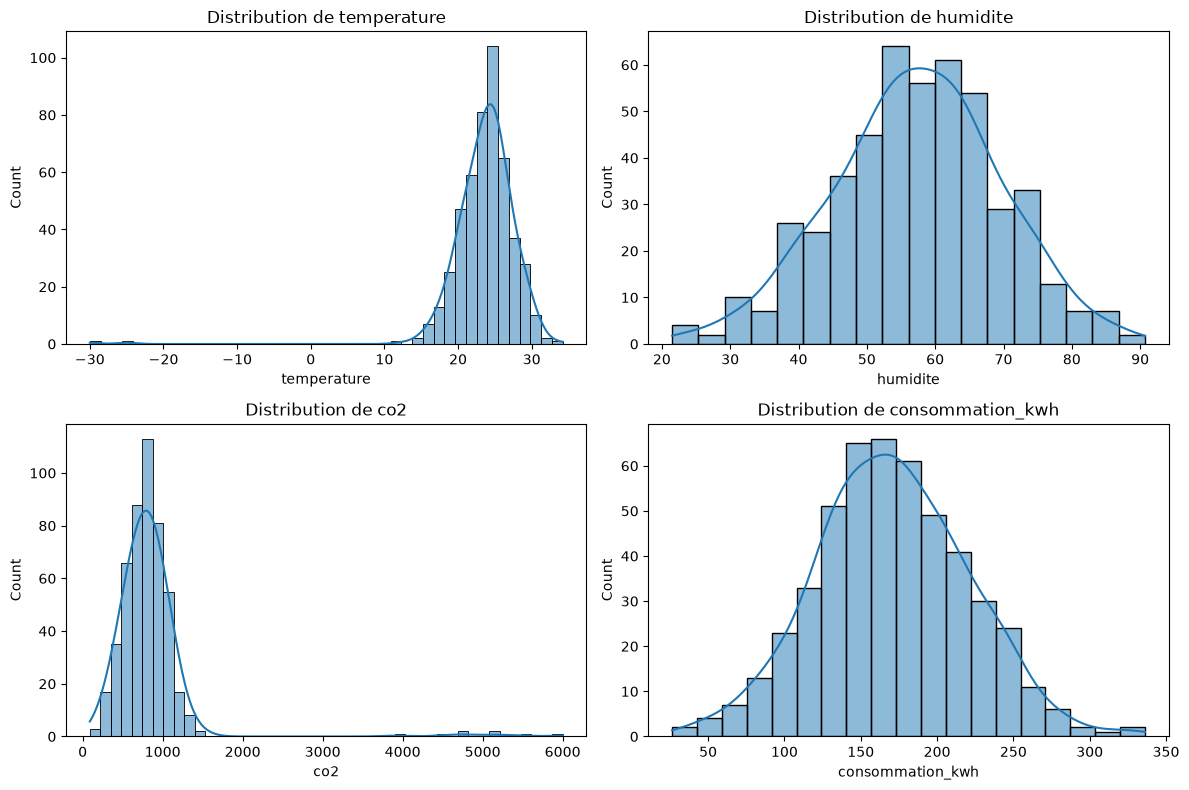

In [376]:
import matplotlib.pyplot as plt
import seaborn as sns

vars_num = ["temperature", "humidite", "co2", "consommation_kwh"]

# Histogrammes (forme des distributions)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, vars_num):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.show()

**Réponse (15).**

- **Distributions (a)** : `humidite` et `consommation_kwh` sont **à peu près symétriques** (coefficient d'asymétrie proche de 0). `co2` est **fortement étirée vers la droite** (quelques valeurs très élevées, ex. 3900) et `temperature` **étirée vers la gauche** (quelques valeurs très basses, ex. −30).
- **Dispersion (b)** : la largeur de la boîte (écart interquartile) montre que `co2` est la plus dispersée ; `temperature` et `humidite` sont plus resserrées autour de leur centre.
- **Valeurs extrêmes (c)** : visibles aux bouts des moustaches — `co2` a des extrêmes hauts, `temperature` des extrêmes bas.
- **Valeurs potentiellement aberrantes (d)** : les points tracés **au-delà des moustaches** du boxplot — nombreux et hauts pour `co2`, bas pour `temperature`. `humidite` et `consommation_kwh` en présentent peu.

### 16) Quelle stratégie pour les valeurs aberrantes ?

**Réponse (16).** Il n'y a pas de méthode unique ; on choisit selon le contexte :

- **Repérer** les aberrantes objectivement, par exemple avec la règle de l'écart interquartile (IQR) : une valeur est suspecte si elle sort de `[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]`, ou via un seuil métier.
- **Traiter** ensuite : (1) si la valeur est *manifestement erronée*, la transformer en valeur manquante puis l'imputer (comme en 12f) ; (2) sinon, la **plafonner/écrêter** (*capping* : ramener aux bornes) pour limiter son influence ; (3) ou la **conserver** si c'est un événement rare mais réel.
- **Éviter** de supprimer les lignes entières (perte de données valides).

Dans ce projet, on privilégie une approche **robuste** : l'imputation par la **médiane** (pipeline, Partie 6) réduit déjà l'impact des aberrantes, la médiane n'étant pas déformée par les extrêmes.

### 17) Fréquence des variables catégorielles

In [377]:
# Fréquence des bâtiments, types de bâtiments, modes de climatisation, états, alertes
for col in ["batiment", "type_batiment", "mode_climatisation", "etat_systeme", "alerte"]:
    print("---", col, "---")
    print(df[col].value_counts())
    print()

--- batiment ---
batiment
b1    92
b5    65
b7    64
b2    60
b4    58
b3    57
b8    53
b6    51
Name: count, dtype: int64

--- type_batiment ---
type_batiment
bureau               210
centre commercial     65
école                 59
hôpital               58
entrepôt              52
université            49
ecole                  1
bureu                  1
entrepot               1
Name: count, dtype: int64

--- mode_climatisation ---
mode_climatisation
normal     267
eco        130
boost       97
normale      1
Name: count, dtype: int64

--- etat_systeme ---
etat_systeme
normal    436
alerte     52
panne      12
Name: count, dtype: int64

--- alerte ---
alerte
non    356
oui    144
Name: count, dtype: int64



**Réponse (17).** `value_counts()` donne, pour chaque colonne catégorielle, l'effectif de chaque catégorie. On lit ainsi les catégories dominantes (ex. `type_batiment` : `bureau` très majoritaire) et les plus rares, ce qui prépare l'analyse du déséquilibre (18) et le choix d'encodage (Partie 4).

### 18) Déséquilibre des classes sur « alerte » ?

In [378]:
# Effectifs et proportions (%) de la variable cible alerte
print(df["alerte"].value_counts())
print((df["alerte"].value_counts(normalize=True) * 100).round(1))

alerte
non    356
oui    144
Name: count, dtype: int64
alerte
non    71.2
oui    28.8
Name: proportion, dtype: float64


**Réponse (18).** **Oui, il y a un déséquilibre.** La classe `non` représente environ **71 %** des observations (356) contre **29 %** pour `oui` (144). Le déséquilibre est **modéré** (≈ 71/29), pas extrême, mais réel : il faudra en tenir compte pour le modèle (d'où la **stratification** au découpage train/test en Partie 3, qui conserve ces proportions dans les deux ensembles).

### 19) Corrélation des variables numériques

On calcule la matrice de corrélation des **vraies** variables numériques (on exclut `id_mesure`, un identifiant) et on la visualise en **heatmap** seaborn : chaque case colorée indique la force et le sens du lien entre deux variables (de −1 à +1).

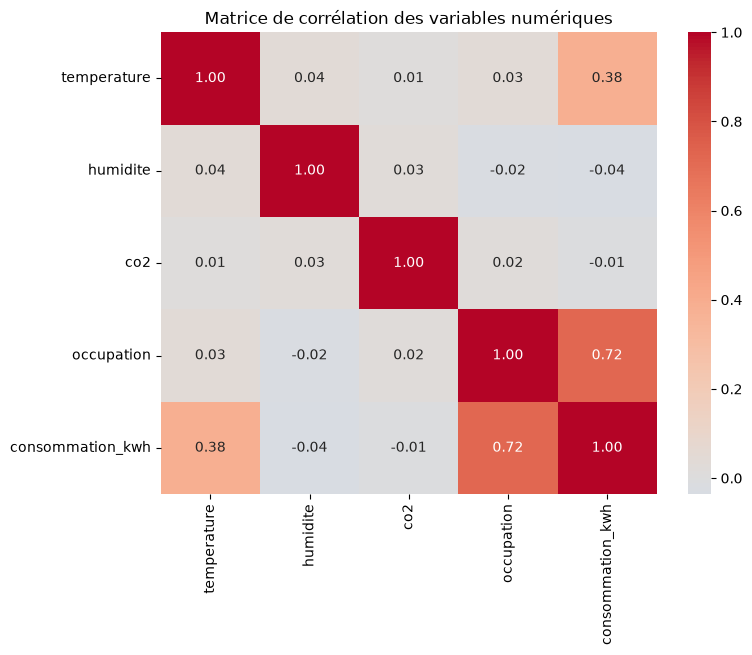

In [379]:
# 19a) Matrice de corrélation en heatmap
num_cols = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

**Réponse (19b).**

- **Corrélations positives** : la plus forte est entre `occupation` et `consommation_kwh` (**≈ 0,72**) — plus il y a de personnes, plus la consommation augmente. Lien positif modéré aussi entre `temperature` et `consommation_kwh` (**≈ 0,38**).
- **Corrélations négatives** : **aucune notable** — toutes les valeurs négatives sont proches de 0 (≈ −0,04), donc négligeables.
- **Variables faiblement corrélées** : `humidite` et `co2` ne sont corrélées à presque rien (|r| < 0,05) ; elles apportent une information indépendante des autres.

## Partie 2 – Séparation X / y

**Principe.** En apprentissage supervisé, on sépare la **cible** `y` (ce qu'on veut prédire) des **variables explicatives** `X` (ce qui sert à prédire). Le modèle apprendra la relation « à partir de X, deviner y ».

#### 1) Définir « alerte » comme cible y

In [381]:
y = df["alerte"]
y.head()

0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: str

#### 2) Variables explicatives X pertinentes

In [382]:
# On retire de X : la cible (alerte), l'identifiant (id_mesure, sans pouvoir prédictif)
# et la date (nécessiterait une extraction de features, hors périmètre ici).
X = df.drop(columns=["alerte", "id_mesure", "date"])
X.columns

Index(['batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2',
       'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme',
       'jour_semaine'],
      dtype='str')

**Justification (X).** On exclut `id_mesure` (simple étiquette, aucune information utile), `date` (donnée temporelle brute qu'il faudrait transformer en année/mois/heure avant usage) et bien sûr `alerte` (la cible). On garde les mesures physiques (`temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`) et les descripteurs catégoriels (`batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine`). Vérification faite : `etat_systeme` ne divulgue pas la cible (pas de fuite).